# Activar el servicio Jupyter

Verificar el entorno Docker existente. Identifique qué tiene corriendo:

bash
# Ver todos los contenedores activos
docker ps

# Ver todas las redes Docker disponibles
docker network ls

# Ver el docker-compose.yml existente
cat docker-compose.yml

# Ejecutar primero

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# 1. Setup y verificación de recursos


In [1]:
# Setup y verificación de recursos
import psutil
import torch
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

print("="*50)
print("🔍 CONFIGURACIÓN DEL SISTEMA")
print("="*50)
print(f"CPU Físicos: {psutil.cpu_count(logical=False)}")
print(f"CPU Lógicos    : {psutil.cpu_count(logical=True)}")
print(f"RAM Total      : {psutil.virtual_memory().total / 1e9:.2f} GB")
print(f"RAM Disponible : {psutil.virtual_memory().available / 1e9:.2f} GB")
print(f"PyTorch Threads: {torch.get_num_threads()}")
print(f"Contenedor     : {'SI' if os.path.exists('/.dockerenv') else 'NO'}")
print("="*50)

# Función de monitoreo
class SystemMonitor:
    def __init__(self):
        self.cpu_history = []
        self.ram_history = []
        self.timestamps = []

    def snapshot(self):
        self.cpu_history.append(psutil.cpu_percent(interval=0.1))
        self.ram_history.append(psutil.virtual_memory().percent)
        self.timestamps.append(time.time())

    def plot(self):
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(self.cpu_history, 'r-', alpha=0.7)
        plt.title('CPU Usage (%)')
        plt.xlabel('Muestras')
        plt.subplot(1,2,2)
        plt.plot(self.ram_history, 'b-', alpha=0.7)
        plt.title('RAM Usage (%)')
        plt.xlabel('Muestras')
        plt.tight_layout()
        plt.show()

monitor = SystemMonitor()

🔍 CONFIGURACIÓN DEL SISTEMA
CPU Físicos: 6
CPU Lógicos    : 12
RAM Total      : 3.76 GB
RAM Disponible : 1.88 GB
PyTorch Threads: 6
Contenedor     : NO


# 2. Dataset de estrés masivo

In [2]:
# Dataset de estrés masivo
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

class ExtremeStressDataset(Dataset):
    def __init__(self, num_samples=200, img_size=3000):
        self.num_samples = num_samples
        self.img_size = img_size
        print(f"⚠️  Generando {num_samples} imágenes de {img_size}x{img_size}")
        print(f"📊 Memoria estimada por imagen: {3*img_size*img_size*4/1e9:.2f} GB")

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Imagen aleatoria de alta resolución
        img = np.random.randn(3, self.img_size, self.img_size).astype(np.float32)
        label = np.random.randint(0, 10)

        # Monitoreo cada 10 muestras
        if idx % 10 == 0:
            monitor.snapshot()

        return torch.from_numpy(img), torch.tensor(label)

# CONFIGURACIÓN - AJUSTA SEGÚN LA RAM DEL EQUIPO
# Para 8GB RAM: usa img_size=2000, batch_size=1
# Para 16GB RAM: usa img_size=3000, batch_size=2
IMG_SIZE = 300  # ⚠️ AJUSTE ESTE VALOR
BATCH_SIZE = 1

dataset = ExtremeStressDataset(num_samples=50, img_size=IMG_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

⚠️  Generando 50 imágenes de 300x300
📊 Memoria estimada por imagen: 0.00 GB


# 3. Modelo neuronal pesado

In [3]:
class ResourceIntensiveModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8))
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = ResourceIntensiveModel()
total_params = sum(p.numel() for p in model.parameters())
print(f"🧠 Parámetros del modelo: {total_params:,}")
print(f"📊 Memoria estimada del modelo: {total_params * 4 / 1e9:.2f} GB")

🧠 Parámetros del modelo: 2,122,186
📊 Memoria estimada del modelo: 0.01 GB


# 4. Entrenamiento con monitoreo

Batch 48: Loss=2.3270
💾 RAM Proceso: 0.44 GB
💿 RAM Sistema: 54.6%
⚙️ CPU Sistema: 43.7%
✅ Epoch 3 completado - Loss promedio: 2.3004

🎯 ENTRENAMIENTO FINALIZADO


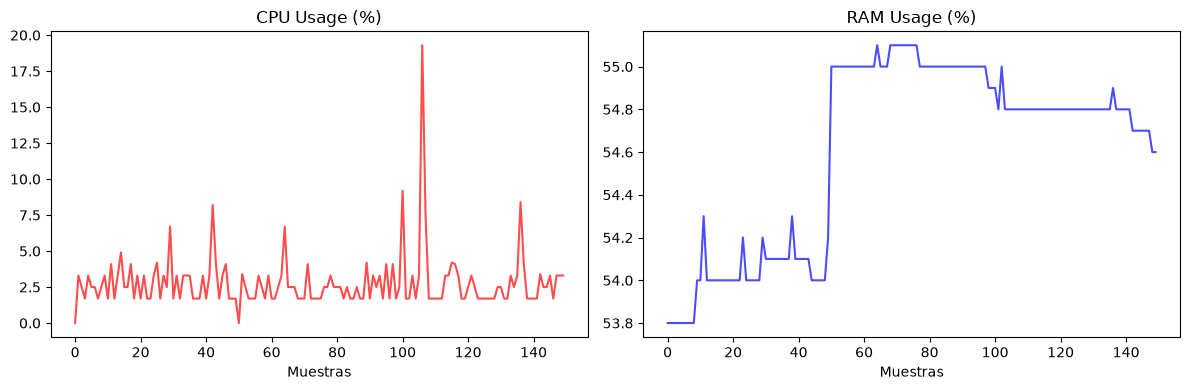

In [4]:
# Entrenamiento con monitoreo
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("🚀 INICIANDO ENTRENAMIENTO DE ESTRÉS")
print("📌 Abre otra terminal y ejecuta: docker stats stress-ai-lab")
print("="*60)

epochs = 3
for epoch in range(epochs):
    epoch_loss = 0
    print(f"\n📈 Epoch {epoch+1}/{epochs}")

    for batch_idx, (data, target) in enumerate(dataloader):
        # Forward pass
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        # Backward pass (momento de máximo estrés)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Monitoreo cada batch
        if batch_idx % 2 == 0:
            mem = psutil.Process().memory_info()
            clear_output(wait=True)
            print(f"Batch {batch_idx}: Loss={loss.item():.4f}")
            print(f"💾 RAM Proceso: {mem.rss/1e9:.2f} GB")
            print(f"💿 RAM Sistema: {psutil.virtual_memory().percent}%")
            print(f"⚙️ CPU Sistema: {psutil.cpu_percent()}%")

        monitor.snapshot()

    print(f"✅ Epoch {epoch+1} completado - Loss promedio: {epoch_loss/len(dataloader):.4f}")

print("\n🎯 ENTRENAMIENTO FINALIZADO")
monitor.plot()

# 5. Alternativa para generar carga en el SO por uso de recursos de hardwsare



In [ ]:
import math
import random

# Cálculos pesados de CPU
def estres_cpu():
    resultados = []
    # Puede modificar el rango para generar mas cilcos
    for i in range(10000):
        resultado = sum(math.sin(x) * math.cos(x) for x in range(100))
        resultados.append(resultado)
    return resultados

estres_cpu()